# Benchmark de Automação, Testes e Documentação

Este notebook compara **Kimi**, **Claude Opus** e **GPT-5.5** em tarefas de engenharia de software:
geração de testes, documentação, scripts de automação e configuração de CI/CD.

**Objetivo:** medir qualidade, utilidade prática, tempo e custo das entregas.

**Métricas:**
- Tokens de entrada e saída
- Tempo de resposta
- Custo estimado
- Execução de testes gerados (pass/fail)
- Qualidade de documentação e scripts

## 1. Instalação das dependências

In [ ]:
# !pip install openai anthropic python-dotenv pandas matplotlib pytest

## 2. Configuração do ambiente

In [1]:
import os
import sys
import time
     import re 
import tempfile
import subprocess
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv

import openai
import anthropic

load_dotenv()

KIMI_API_KEY = os.getenv("KIMI_API_KEY")
ANTHROPIC_API_KEY = os.getenv("ANTHROPIC_API_KEY")
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")

kimi_client = openai.OpenAI(api_key=KIMI_API_KEY, base_url="https://api.moonshot.ai/v1")
anthropic_client = anthropic.Anthropic(api_key=ANTHROPIC_API_KEY)
openai_client = openai.OpenAI(api_key=OPENAI_API_KEY)


## 3. Tabela de preços

In [2]:
# Preços por 1M tokens (USD) — verificados em 2026-08-03.
# As chaves precisam bater com o campo "provider" retornado por cada call_*().
PRICES = {
    "kimi":        {"input":  3.00, "output": 15.00},  # kimi-k3 (Moonshot)
    "claude-opus": {"input":  5.00, "output": 25.00},  # claude-opus-5 (Anthropic)
    "gpt-5.6-terra": {"input":  2.00, "output": 12.00},  # gpt-5.6-terra (OpenAI)
}


## 4. Funções padronizadas de chamada

In [3]:
def call_kimi(system_prompt, user_prompt, model="kimi-k3"):
    start = time.time()
    response = kimi_client.chat.completions.create(
        model=model,
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_prompt}
        ],
        temperature=1.0
    )
    elapsed = time.time() - start
    return {
        "provider": "kimi",
        "model": model,
        "response": response.choices[0].message.content,
        "input_tokens": response.usage.prompt_tokens,
        "output_tokens": response.usage.completion_tokens,
        "total_tokens": response.usage.total_tokens,
        "time_seconds": elapsed
    }

def call_claude(system_prompt, user_prompt, model="claude-opus-5"):
    start = time.time()
    # O claude-opus-5 não aceita temperature (400 invalid_request_error) e vem com
    # thinking ligado por padrão, que consome parte do max_tokens — por isso o
    # limite é mais folgado que os 4096 usados no opus-4-6.
    response = anthropic_client.messages.create(
        model=model,
        max_tokens=16000,
        system=system_prompt,
        messages=[{"role": "user", "content": user_prompt}]
    )
    elapsed = time.time() - start
    # Com thinking ligado, content[0] é um bloco 'thinking'; o texto vem depois.
    text = next(b.text for b in response.content if b.type == "text")
    return {
        "provider": "claude-opus",
        "model": model,
        "response": text,
        "input_tokens": response.usage.input_tokens,
        "output_tokens": response.usage.output_tokens,
        "total_tokens": response.usage.input_tokens + response.usage.output_tokens,
        "time_seconds": elapsed
    }

def call_openai(system_prompt, user_prompt, model="gpt-5.6-terra"):
    start = time.time()
    # temperature é omitido de propósito: o gpt-5.5 rejeitava qualquer valor != 1
    # (400 unsupported_value) e o padrão do provider funciona em qualquer modelo.
    response = openai_client.chat.completions.create(
        model=model,
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_prompt}
        ]
    )
    elapsed = time.time() - start
    return {
        "provider": "gpt-5.6-terra",
        "model": model,
        "response": response.choices[0].message.content,
        "input_tokens": response.usage.prompt_tokens,
        "output_tokens": response.usage.completion_tokens,
        "total_tokens": response.usage.total_tokens,
        "time_seconds": elapsed
    }


## 5. Funções auxiliares

In [4]:
def calculate_cost(provider, input_tokens, output_tokens):
    prices = PRICES.get(provider, {})
    input_cost = (input_tokens / 1_000_000) * prices.get("input", 0)
    output_cost = (output_tokens / 1_000_000) * prices.get("output", 0)
    return round(input_cost + output_cost, 6)

# Nome do provider por função de chamada — usado quando a call falha, para que a
# linha de erro use a mesma chave de PRICES e não vire uma categoria extra nos gráficos.
CALLER_PROVIDERS = {
    "call_kimi": "kimi",
    "call_claude": "claude-opus",
    "call_openai": "gpt-5.6-terra",
}

# Colunas métricas — os textos gerados ficam fora daqui.
METRIC_COLUMNS = [
    "task", "provider", "model",
    "input_tokens", "output_tokens", "total_tokens",
    "time_seconds", "cost_usd", "tests_passed",
]

def metrics(df):
    """Versão só com métricas, para exibir a tabela sem os textos longos."""
    return df[METRIC_COLUMNS]

def extract_code(response, language="python"):
    pattern = rf"```{language}\n(.*?)\n```"
    match = re.search(pattern, response, re.DOTALL)
    if match:
        return match.group(1).strip()
    match = re.search(r"```\n(.*?)\n```", response, re.DOTALL)
    if match:
        return match.group(1).strip()
    return response.strip()

def run_pytest(code):
    with tempfile.NamedTemporaryFile(mode="w", suffix="_test.py", delete=False) as f:
        f.write(code)
        temp_path = f.name
    try:
        result = subprocess.run(
            [sys.executable, "-m", "pytest", temp_path, "-v"],  # mesmo Python do notebook
            capture_output=True,
            text=True,
            timeout=30
        )
        passed = result.returncode == 0
        summary = result.stdout if passed else result.stdout + "\n" + result.stderr
        return {
            "tests_passed": passed,
            "summary": summary[:500]
        }
    except Exception as e:
        return {"tests_passed": False, "summary": str(e)}
    finally:
        os.unlink(temp_path)

def run_benchmark(system_prompt, user_prompt, task_name="tarefa", code_lang="python", run_tests=False):
    results = []
    callers = [call_kimi, call_claude, call_openai]
    for caller in callers:
        try:
            result = caller(system_prompt, user_prompt)
            result["cost_usd"] = calculate_cost(
                result["provider"],
                result["input_tokens"],
                result["output_tokens"]
            )
            result["task"] = task_name
            extracted = extract_code(result["response"], language=code_lang)
            result["extracted_output"] = extracted
            if run_tests:
                test_result = run_pytest(extracted)
                result["tests_passed"] = test_result["tests_passed"]
                result["test_summary"] = test_result["summary"]
            else:
                result["tests_passed"] = None
                result["test_summary"] = ""
            results.append(result)
        except Exception as e:
            results.append({
                "provider": CALLER_PROVIDERS.get(caller.__name__, caller.__name__),
                "model": "error",
                "response": f"[ERRO] {type(e).__name__}: {e}",
                "input_tokens": 0,
                "output_tokens": 0,
                "total_tokens": 0,
                "time_seconds": 0,
                "cost_usd": 0,
                "task": task_name,
                "extracted_output": "",
                "tests_passed": False,
                "test_summary": f"{type(e).__name__}: {e}"
            })
    df = pd.DataFrame(results)
    # Mantém "response", "extracted_output" e "test_summary": as células seguintes usam esses textos.
    return df[METRIC_COLUMNS + ["response", "extracted_output", "test_summary"]]


## 6. Benchmark 1 — Geração de testes unitários

In [5]:
system_tests = """
Você é um engenheiro de qualidade de software.
Gere apenas código Python com testes pytest completos.
Não inclua explicações fora do código.
"""

user_tests = """
Crie testes pytest para a seguinte função:

def discount_price(price, discount_percent):
    if price < 0 or discount_percent < 0 or discount_percent > 100:
        raise ValueError(")
    return round(price * (1 - discount_percent / 100), 2)

Cobre casos normais, de borda e de erro.
"""

df_tests = run_benchmark(system_tests, user_tests, task_name="geracao_testes", run_tests=True)
metrics(df_tests)


,task,provider,model,input_tokens,output_tokens,total_tokens,time_seconds,cost_usd,tests_passed
0,geracao_testes,kimi,kimi-k3,213,11154,11367,249.479653,0.167949,True
1,geracao_testes,claude-opus,claude-opus-5,168,3034,3202,33.626525,0.076690,False
2,geracao_testes,gpt-5.6-terra,gpt-5.6-terra,113,651,764,8.824410,0.008038,False


In [6]:
for _, row in df_tests.iterrows():
    out = str(row["extracted_output"])
    print(f"\n=== {row['provider'].upper()} ===")
    print(f"Testes passaram: {row['tests_passed']}")
    print(out[:500] + ("..." if len(out) > 500 else ""))



=== KIMI ===
Testes passaram: True
"""
Testes pytest para a função discount_price.

Observação: o código original continha um erro de sintaxe na linha do
`raise ValueError(")` (string sem fechamento). A função abaixo é a versão
corrigida utilizada como alvo dos testes.
"""

import pytest


# ---------------------------------------------------------------------------
# Função sob teste (versão corrigida)
# ---------------------------------------------------------------------------
def discount_price(price, discount_percent):
    i...

=== CLAUDE-OPUS ===
Testes passaram: False
"""
Testes pytest para a função discount_price.

A função original possuía um erro de sintaxe (`raise ValueError(")`).
Aqui ela é reproduzida corrigida, mantendo o comportamento pretendido,
para que a suíte de testes possa ser executada.
"""

import math

import pytest


# ---------------------------------------------------------------------------
# Código sob teste
# ---------------------------------------------

## 7. Benchmark 2 — Geração de documentação (docstrings + README)

In [7]:
system_docs = """
Você é um technical writer sênior.
Escreva documentação técnica clara, objetiva e bem estruturada em Markdown.
"""

user_docs = """
Gere um README.md para uma API REST de gerenciamento de tarefas (Todo List) feita em FastAPI.
Inclua: descrição, endpoints principais, exemplo de requisição, instalação e tecnologias usadas.
"""

df_docs = run_benchmark(system_docs, user_docs, task_name="documentacao_readme")
metrics(df_docs)


,task,provider,model,input_tokens,output_tokens,total_tokens,time_seconds,cost_usd,tests_passed
0,documentacao_readme,kimi,kimi-k3,186,2827,3013,62.801508,0.042963,None
1,documentacao_readme,claude-opus,claude-opus-5,130,4489,4619,44.840453,0.112875,None
2,documentacao_readme,gpt-5.6-terra,gpt-5.6-terra,76,1640,1716,12.709894,0.019832,None


In [8]:
for _, row in df_docs.iterrows():
    text = str(row["response"])
    print(f"\n=== {row['provider'].upper()} | {row['model']} ===")
    print(text[:700] + ("..." if len(text) > 700 else ""))



=== KIMI | kimi-k3 ===
# README.md — Todo List API

```markdown
# 📝 Todo List API

API REST para gerenciamento de tarefas (Todo List) desenvolvida com **FastAPI**.
Permite criar, listar, consultar, atualizar e remover tarefas de forma simples e performática.

## ✨ Funcionalidades

- ✅ Criar tarefas com título, descrição e status de conclusão
- 📋 Listar todas as tarefas, com filtro opcional por status
- 🔍 Consultar uma tarefa específica por ID
- ✏️ Atualizar tarefas existentes (total ou parcialmente)
- 🗑️ Remover tarefas
- 📖 Documentação interativa automática (Swagger UI e ReDoc)

## 🚀 Tecnologias Utilizadas

| Tecnologia | Versão | Finalidade |
|------------|--------|------------|
| [Python](https://www.python.org...

=== CLAUDE-OPUS | claude-opus-5 ===
# Todo List API

> API REST para gerenciamento de tarefas, construída com **FastAPI**, **SQLAlchemy** e **Pydantic**.

[![Python](https://img.shields.io/badge/python-3.11+-blue.svg)](https://www.python.org/)
[![FastAPI](https://img.shi

## 8. Benchmark 3 — Script de automação

In [9]:
system_auto = """
Você é um engenheiro de automação.
Gere apenas scripts Python executáveis, sem explicações fora do código.
"""

user_auto = """
Crie um script Python que monitore uma pasta chamada 'downloads' e mova automaticamente
arquivos .pdf para uma pasta 'pdfs', arquivos .jpg e .png para 'imagens', e outros para 'outros'.
O script deve rodar em loop e tratar erros de forma elegante.
"""

df_auto = run_benchmark(system_auto, user_auto, task_name="script_automacao")
metrics(df_auto)


,task,provider,model,input_tokens,output_tokens,total_tokens,time_seconds,cost_usd,tests_passed
0,script_automacao,kimi,kimi-k3,200,3546,3746,96.657832,0.053790,None
1,script_automacao,claude-opus,claude-opus-5,155,3161,3316,31.999797,0.079800,None
2,script_automacao,gpt-5.6-terra,gpt-5.6-terra,98,850,948,9.739346,0.010396,None


In [10]:
for _, row in df_auto.iterrows():
    out = str(row["extracted_output"])
    print(f"\n=== {row['provider'].upper()} ===")
    print(out[:500] + ("..." if len(out) > 500 else ""))



=== KIMI ===
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Organizador automático da pasta 'downloads'.

Regras:
    .pdf          -> downloads/pdfs
    .jpg / .png   -> downloads/imagens
    demais tipos  -> downloads/outros

Uso:
    python monitor_downloads.py
    (Ctrl+C para encerrar)
"""

from __future__ import annotations

import logging
import shutil
import sys
import time
from pathlib import Path

# ----------------------------- Configurações -------------------------------- #
PASTA_DOWNLOADS =...

=== CLAUDE-OPUS ===
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Monitor de pasta 'downloads' com organização automática de arquivos.

Regras:
    .pdf            -> pdfs/
    .jpg .jpeg .png -> imagens/
    qualquer outro  -> outros/

Uso:
    python organizador.py
    python organizador.py --base ./downloads --intervalo 5
    python organizador.py --uma-vez        # executa apenas um ciclo
"""

from __future__ import annotations

import argparse
import logging
import o

## 9. Benchmark 4 — Configuração de CI/CD

In [11]:
system_cicd = """
Você é um engenheiro DevOps.
Gere apenas arquivos de configuração YAML válidos, sem explicações.
"""

user_cicd = """
Crie um workflow do GitHub Actions para um projeto Python que:
1. Execute em push e pull request para a branch main.
2. Instale dependências de requirements.txt.
3. Execute pytest.
4. Verifique formatação com flake8.
Use uma matrix com Python 3.10 e 3.11.
"""

df_cicd = run_benchmark(system_cicd, user_cicd, task_name="config_cicd", code_lang="yaml")
metrics(df_cicd)


,task,provider,model,input_tokens,output_tokens,total_tokens,time_seconds,cost_usd,tests_passed
0,config_cicd,kimi,kimi-k3,197,1169,1366,33.918891,0.018126,None
1,config_cicd,claude-opus,claude-opus-5,156,408,564,5.603602,0.010980,None
2,config_cicd,gpt-5.6-terra,gpt-5.6-terra,102,185,287,2.433142,0.002424,None


In [12]:
for _, row in df_cicd.iterrows():
    print(f"\n=== {row['provider'].upper()} ===")
    print(row["extracted_output"])



=== KIMI ===
name: Python CI

on:
  push:
    branches: [main]
  pull_request:
    branches: [main]

jobs:
  test:
    runs-on: ubuntu-latest

    strategy:
      fail-fast: false
      matrix:
        python-version: ["3.10", "3.11"]

    steps:
      - name: Checkout repository
        uses: actions/checkout@v4

      - name: Set up Python ${{ matrix.python-version }}
        uses: actions/setup-python@v5
        with:
          python-version: ${{ matrix.python-version }}
          cache: pip

      - name: Install dependencies
        run: |
          python -m pip install --upgrade pip
          pip install -r requirements.txt
          pip install pytest flake8

      - name: Lint with flake8
        run: flake8 .

      - name: Run tests with pytest
        run: pytest

=== CLAUDE-OPUS ===
name: CI

on:
  push:
    branches: [main]
  pull_request:
    branches: [main]

jobs:
  build:
    runs-on: ubuntu-latest
    strategy:
      fail-fast: false
      matrix:
        python-ve

## 10. Consolidação dos resultados

In [13]:
df_all = pd.concat([df_tests, df_docs, df_auto, df_cicd], ignore_index=True)
metrics(df_all)


,task,provider,model,input_tokens,output_tokens,total_tokens,time_seconds,cost_usd,tests_passed
0,geracao_testes,kimi,kimi-k3,213,11154,11367,249.479653,0.167949,True
1,geracao_testes,claude-opus,claude-opus-5,168,3034,3202,33.626525,0.076690,False
2,geracao_testes,gpt-5.6-terra,gpt-5.6-terra,113,651,764,8.824410,0.008038,False
3,documentacao_readme,kimi,kimi-k3,186,2827,3013,62.801508,0.042963,None
4,documentacao_readme,claude-opus,claude-opus-5,130,4489,4619,44.840453,0.112875,None
5,documentacao_readme,gpt-5.6-terra,gpt-5.6-terra,76,1640,1716,12.709894,0.019832,None
6,script_automacao,kimi,kimi-k3,200,3546,3746,96.657832,0.053790,None
7,script_automacao,claude-opus,claude-opus-5,155,3161,3316,31.999797,0.079800,None
8,script_automacao,gpt-5.6-terra,gpt-5.6-terra,98,850,948,9.739346,0.010396,None
9,config_cicd,kimi,kimi-k3,197,1169,1366,33.918891,0.018126,None


## 11. Visualização comparativa

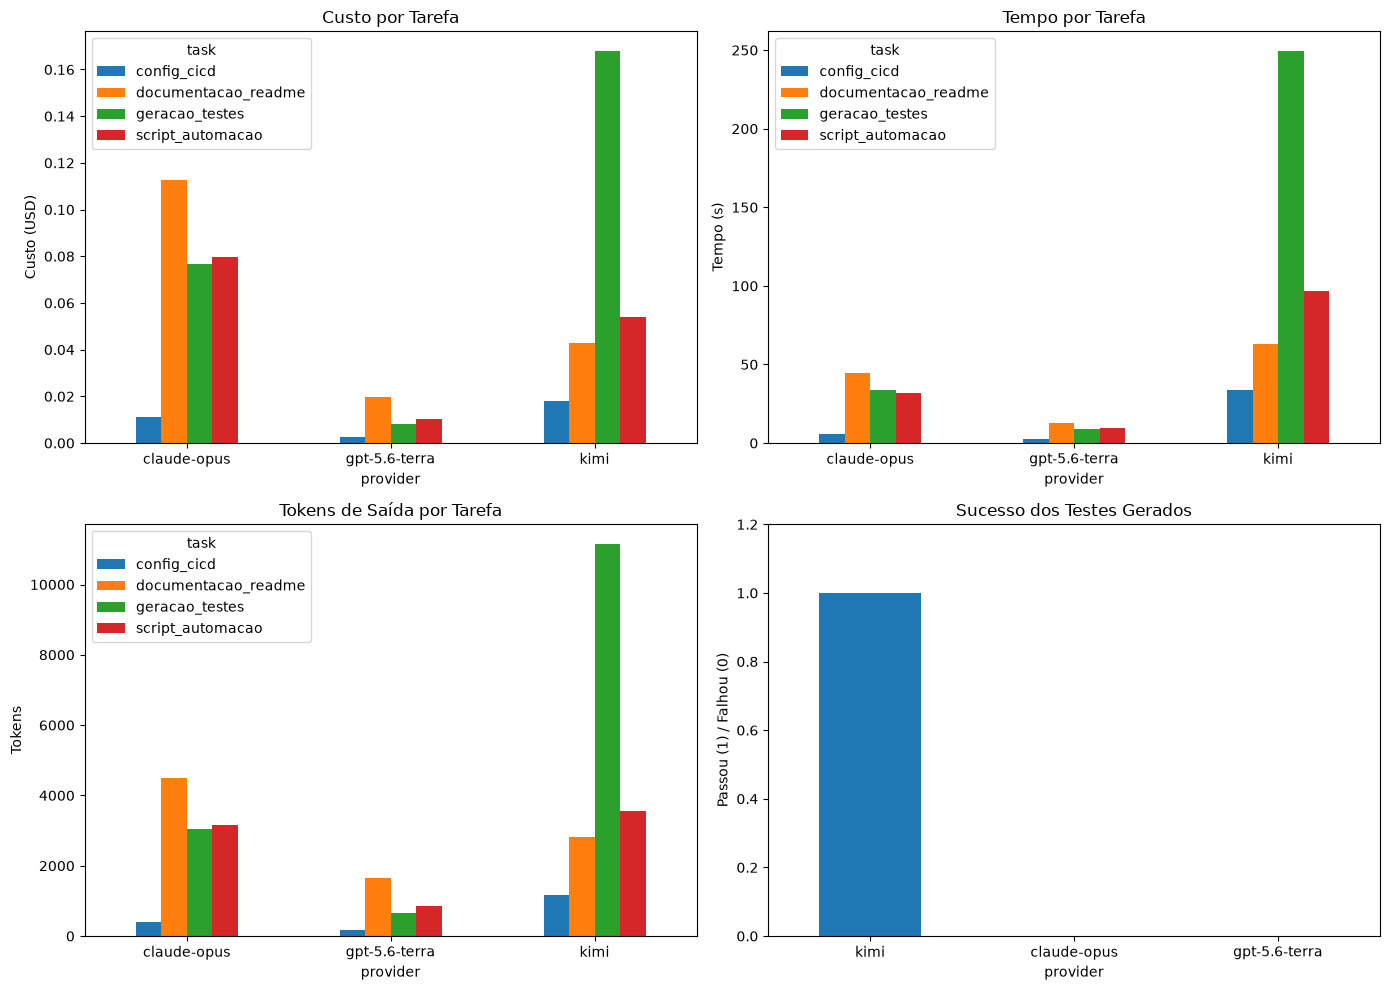

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

cost_pivot = df_all.pivot(index="provider", columns="task", values="cost_usd")
cost_pivot.plot.bar(ax=axes[0, 0], title="Custo por Tarefa", rot=0)
axes[0, 0].set_ylabel("Custo (USD)")

time_pivot = df_all.pivot(index="provider", columns="task", values="time_seconds")
time_pivot.plot.bar(ax=axes[0, 1], title="Tempo por Tarefa", rot=0)
axes[0, 1].set_ylabel("Tempo (s)")

token_pivot = df_all.pivot(index="provider", columns="task", values="output_tokens")
token_pivot.plot.bar(ax=axes[1, 0], title="Tokens de Saída por Tarefa", rot=0)
axes[1, 0].set_ylabel("Tokens")

# Apenas para a tarefa de testes, plota sucesso
tests_only = df_all[df_all["task"] == "geracao_testes"].copy()
tests_only["tests_passed_int"] = tests_only["tests_passed"].astype(int)
tests_only.plot.bar(x="provider", y="tests_passed_int", ax=axes[1, 1], title="Sucesso dos Testes Gerados", legend=False, rot=0)
axes[1, 1].set_ylabel("Passou (1) / Falhou (0)")
axes[1, 1].set_ylim(0, 1.2)

plt.tight_layout()
plt.show()

## 12. Score final por provider

In [15]:
summary = df_all.groupby("provider").agg(
    total_tasks=("task", "count"),
    total_cost=("cost_usd", "sum"),
    avg_time=("time_seconds", "mean"),
    total_tokens=("total_tokens", "sum")
).reset_index()

test_summary = df_all[df_all["task"] == "geracao_testes"][["provider", "tests_passed"]].copy()
test_summary["tests_passed_int"] = test_summary["tests_passed"].astype(int)
test_summary = test_summary.groupby("provider")["tests_passed_int"].sum().reset_index()

summary = summary.merge(test_summary, on="provider", how="left").fillna(0)
summary = summary.round(4)
summary

,provider,total_tasks,total_cost,avg_time,total_tokens,tests_passed_int
0,claude-opus,4,0.2803,29.0176,11701,0
1,gpt-5.6-terra,4,0.0407,8.4267,3715,0
2,kimi,4,0.2828,110.7145,19492,1


## 13. Exportação

In [16]:
# Métricas (planilha enxuta) + textos gerados em arquivo separado
metrics(df_all).to_csv("benchmark_automacao_testes_documentacao_resultados.csv", index=False)
summary.to_csv("benchmark_automacao_testes_documentacao_resumo.csv", index=False)
df_all.to_csv("benchmark_automacao_testes_documentacao_respostas.csv", index=False)
print("Resultados salvos com sucesso!")


Resultados salvos com sucesso!


## 14. Perguntas para análise

1. Qual modelo gerou testes unitários executáveis corretamente?
2. Quem produziu o README mais completo e bem estruturado?
3. O script de automação gerado está robusto o suficiente para uso real? O que falta?
4. O workflow de CI/CD gerado cobre todos os requisitos solicitados?
5. Considerando custo e qualidade, qual modelo se destacou neste benchmark?